## Preparación de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

In [3]:
datos = pd.read_csv('/content/datos_tratados.csv')

In [4]:
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Total_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.186667,4.0
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,1.996667,2.0
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,2.0
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,5.0
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,3.0


In [5]:
datos = datos.drop(columns=['customerID'])

In [6]:
datos.shape[1]

22

In [7]:
datos.columns.tolist()

['Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total',
 'Cuentas_Diarias',
 'Total_Servicios']

In [8]:
categoricas = datos.select_dtypes(include='object').columns.tolist()
print("Columnas categóricas:", categoricas)

Columnas categóricas: ['customer.gender', 'phone.MultipleLines', 'internet.InternetService', 'account.Contract', 'account.PaymentMethod']


In [9]:
datos_encoded = pd.get_dummies(datos, columns=categoricas, drop_first=False)

In [10]:
datos_encoded.head()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,...,internet.InternetService_DSL,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0.0,1.0,0.0,1.0,...,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,0.0,0.0,0.0,0.0,...,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,0.0,0.0,1.0,0.0,...,False,True,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0.0,1.0,1.0,0.0,...,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0.0,0.0,0.0,1.0,...,False,True,False,True,False,False,False,False,False,True


In [11]:
conteo = datos_encoded['Churn'].value_counts()
proporcion = datos_encoded['Churn'].value_counts(normalize=True) * 100

In [12]:
print("Conteo:")
print(conteo.rename({1: 'Evasión', 0: 'Permanece'}))
print("\nProporción:")
print(proporcion.rename({1: 'Evasión', 0: 'Permanece'}).round(2))
print(f"\nRatio de desbalance: {conteo[0]/conteo[1]:.1f}:1")

Conteo:
Churn
Permanece    5174
Evasión      1869
Name: count, dtype: int64

Proporción:
Churn
Permanece    73.46
Evasión      26.54
Name: proportion, dtype: float64

Ratio de desbalance: 2.8:1


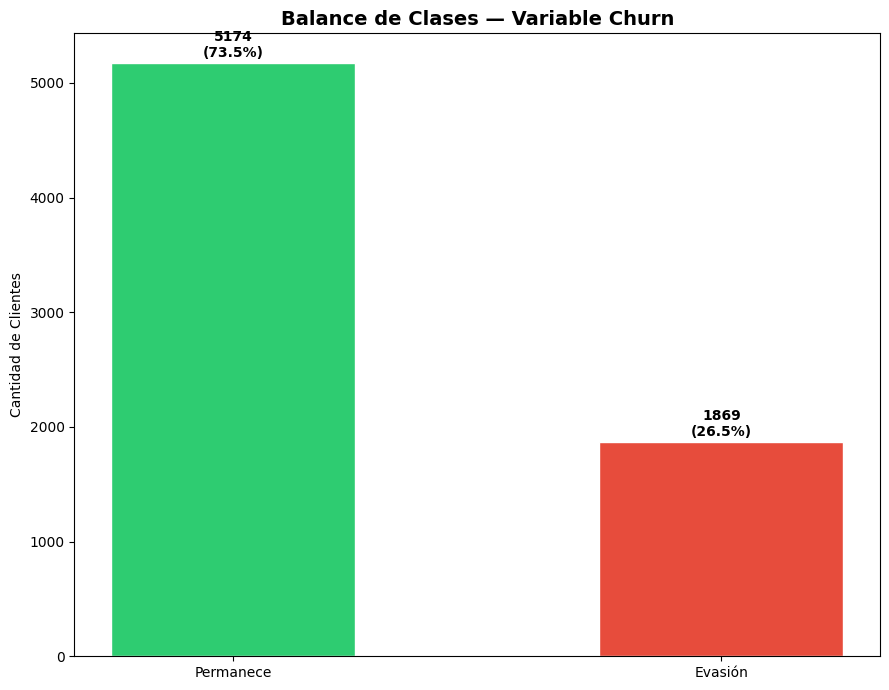

In [13]:
plt.figure(figsize=(9, 7))
plt.bar(['Permanece', 'Evasión'], conteo.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
plt.title('Balance de Clases — Variable Churn', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Clientes')
for i, (v, p) in enumerate(zip(conteo.values, proporcion.values)):
    plt.text(i, v + 50, f'{v}\n({p:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:
X = datos_encoded.drop(columns=['Churn'])
y = datos_encoded['Churn']

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f"Shape después de limpiar: {X.shape}")
print(f"NaN en X: {X.isnull().sum().sum()}")
print(f"NaN en y: {y.isnull().sum()}")

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Shape después de limpiar: (5517, 31)
NaN en X: 0
NaN en y: 0

Train: (6017, 31) | Test: (1505, 31)


In [16]:
print("datos_encoded shape:", datos_encoded.shape)
print("NaN en Churn:", datos_encoded['Churn'].isnull().sum())

datos_encoded shape: (7043, 32)
NaN en Churn: 0


## Correlación y selección de variables

In [19]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (6017, 31) | Test: (1505, 31)


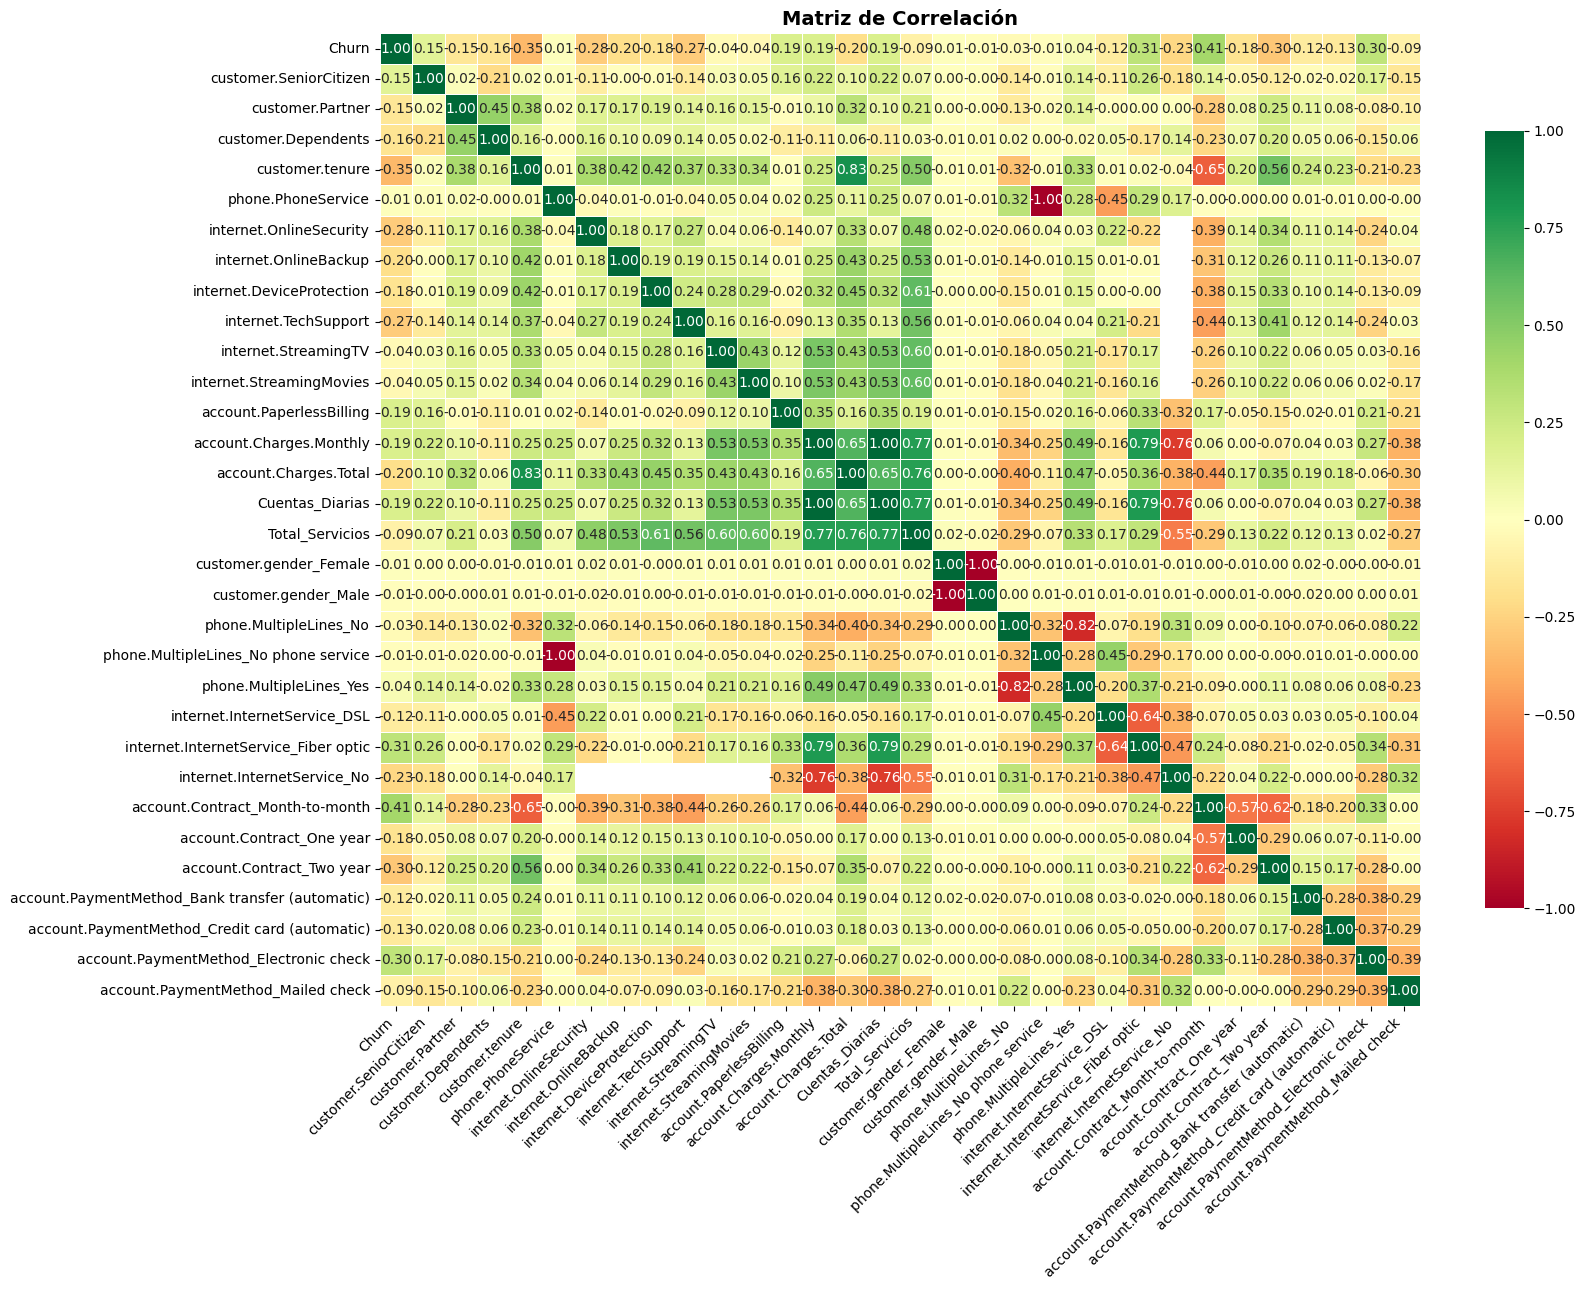


Variables más correlacionadas con Churn:
account.Contract_Month-to-month                    0.405
internet.InternetService_Fiber optic               0.308
account.PaymentMethod_Electronic check             0.302
account.Charges.Monthly                            0.193
Cuentas_Diarias                                    0.193
account.PaperlessBilling                           0.192
customer.SeniorCitizen                             0.151
phone.MultipleLines_Yes                            0.040
phone.PhoneService                                 0.012
customer.gender_Female                             0.009
customer.gender_Male                              -0.009
phone.MultipleLines_No phone service              -0.012
phone.MultipleLines_No                            -0.033
internet.StreamingTV                              -0.037
internet.StreamingMovies                          -0.040
Total_Servicios                                   -0.086
account.PaymentMethod_Mailed check            

In [21]:
correlacion = datos_encoded.corr()

plt.figure(figsize=(17, 13))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nVariables más correlacionadas con Churn:")
corr_churn = correlacion['Churn'].drop('Churn').sort_values(ascending=False)
print(corr_churn.round(3).to_string())

/tmp/ipykernel_7597/4046436345.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipykernel_7597/4046436345.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


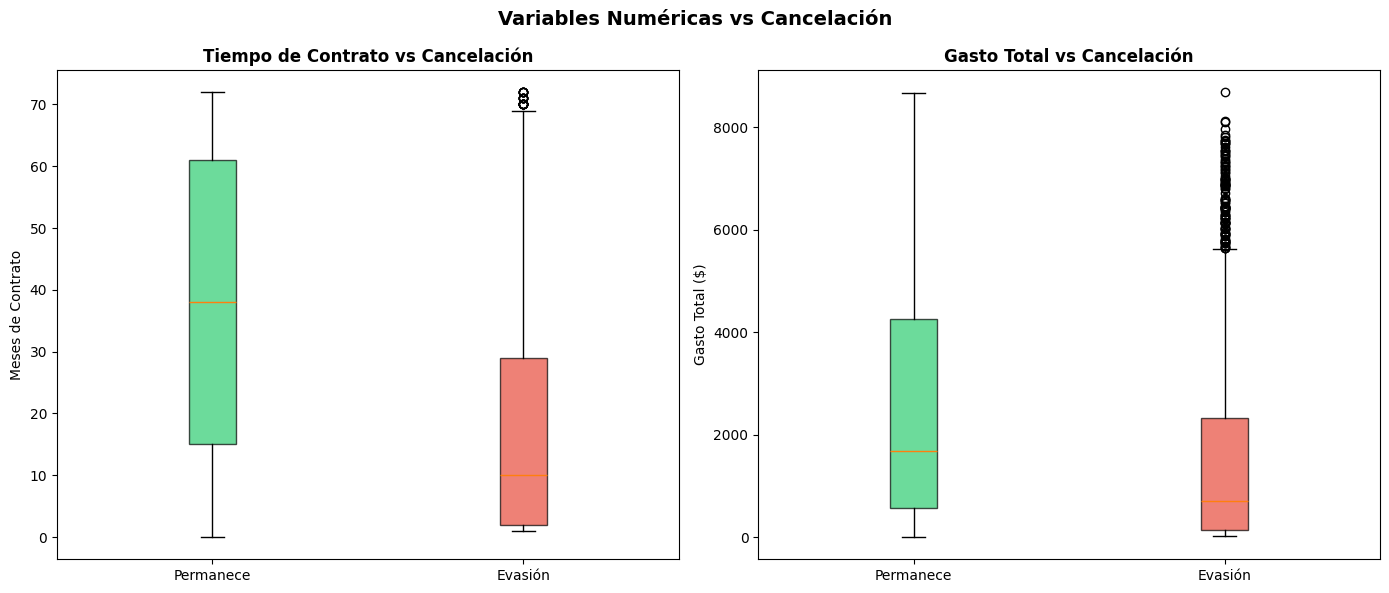

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Variables Numéricas vs Cancelación', fontsize=14, fontweight='bold')

axes[0].boxplot(
    [datos_encoded[datos_encoded['Churn']==0]['customer.tenure'],
     datos_encoded[datos_encoded['Churn']==1]['customer.tenure']],
    labels=['Permanece', 'Evasión'],
    patch_artist=True,
    boxprops=dict(facecolor='#2ecc71', alpha=0.7),
)

axes[0].findobj(plt.matplotlib.patches.PathPatch)[1].set_facecolor('#e74c3c')
axes[0].set_title('Tiempo de Contrato vs Cancelación', fontweight='bold')
axes[0].set_ylabel('Meses de Contrato')


axes[1].boxplot(
    [datos_encoded[datos_encoded['Churn']==0]['account.Charges.Total'],
     datos_encoded[datos_encoded['Churn']==1]['account.Charges.Total']],
    labels=['Permanece', 'Evasión'],
    patch_artist=True,
    boxprops=dict(facecolor='#2ecc71', alpha=0.7),
)
axes[1].findobj(plt.matplotlib.patches.PathPatch)[1].set_facecolor('#e74c3c')
axes[1].set_title('Gasto Total vs Cancelación', fontweight='bold')
axes[1].set_ylabel('Gasto Total ($)')

plt.tight_layout()
plt.show()

## Modelo

In [29]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


  Regresión Logística
              precision    recall  f1-score   support

   Permanece       0.81      0.81      0.81       742
     Evasión       0.81      0.82      0.82       763

    accuracy                           0.81      1505
   macro avg       0.81      0.81      0.81      1505
weighted avg       0.81      0.81      0.81      1505

AUC-ROC: 0.8991

  Random Forest
              precision    recall  f1-score   support

   Permanece       0.81      0.84      0.82       742
     Evasión       0.84      0.80      0.82       763

    accuracy                           0.82      1505
   macro avg       0.82      0.82      0.82      1505
weighted avg       0.82      0.82      0.82      1505

AUC-ROC: 0.8983


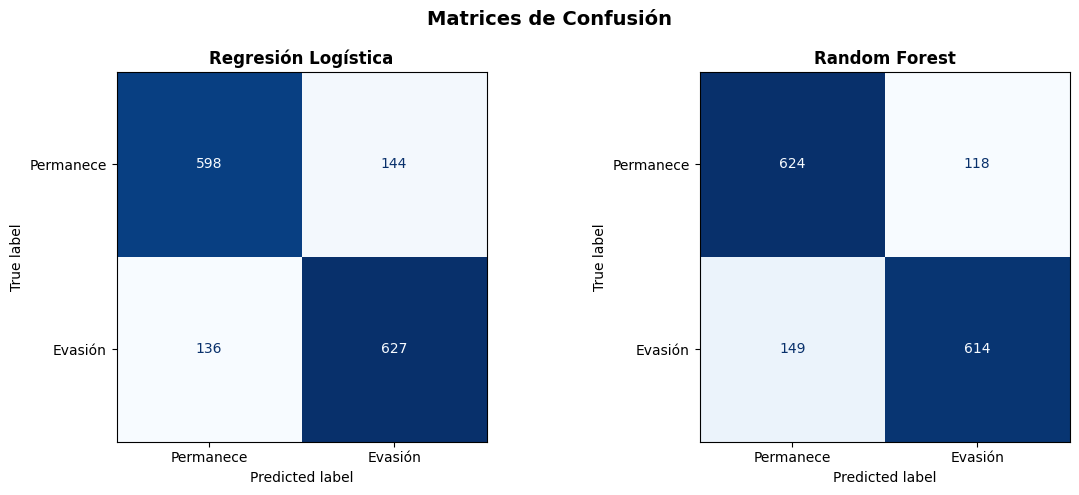


Resumen comparativo:
Métrica               Reg. Logística   Random Forest
----------------------------------------------------
Accuracy                      0.8140          0.8226
AUC-ROC                       0.8991          0.8983


In [36]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, accuracy_score)

modelos = [
    ('Regresión Logística', y_pred_lr, y_prob_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf)
]

for nombre, y_pred, y_prob in modelos:
    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=['Permanece', 'Evasión']))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold')

for ax, (nombre, y_pred, _) in zip(axes, modelos):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Permanece', 'Evasión']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nResumen comparativo:")
print(f"{'Métrica':<20} {'Reg. Logística':>15} {'Random Forest':>15}")
print("-" * 52)
for nombre, y_pred, y_prob in modelos:
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
print(f"{'Accuracy':<20} {accuracy_score(y_test, y_pred_lr):>15.4f} {accuracy_score(y_test, y_pred_rf):>15.4f}")
print(f"{'AUC-ROC':<20} {roc_auc_score(y_test, y_prob_lr):>15.4f} {roc_auc_score(y_test, y_prob_rf):>15.4f}")

In [38]:
print("Accuracy Train vs Test:")
print(f"LR — Train: {lr.score(X_train_scaled, y_train):.4f} | Test: {lr.score(X_test_scaled, y_test):.4f}")
print(f"RF — Train: {rf.score(X_train, y_train):.4f} | Test: {rf.score(X_test, y_test):.4f}")

Accuracy Train vs Test:
LR — Train: 0.8213 | Test: 0.8140
RF — Train: 0.9997 | Test: 0.8226


## Interpretación

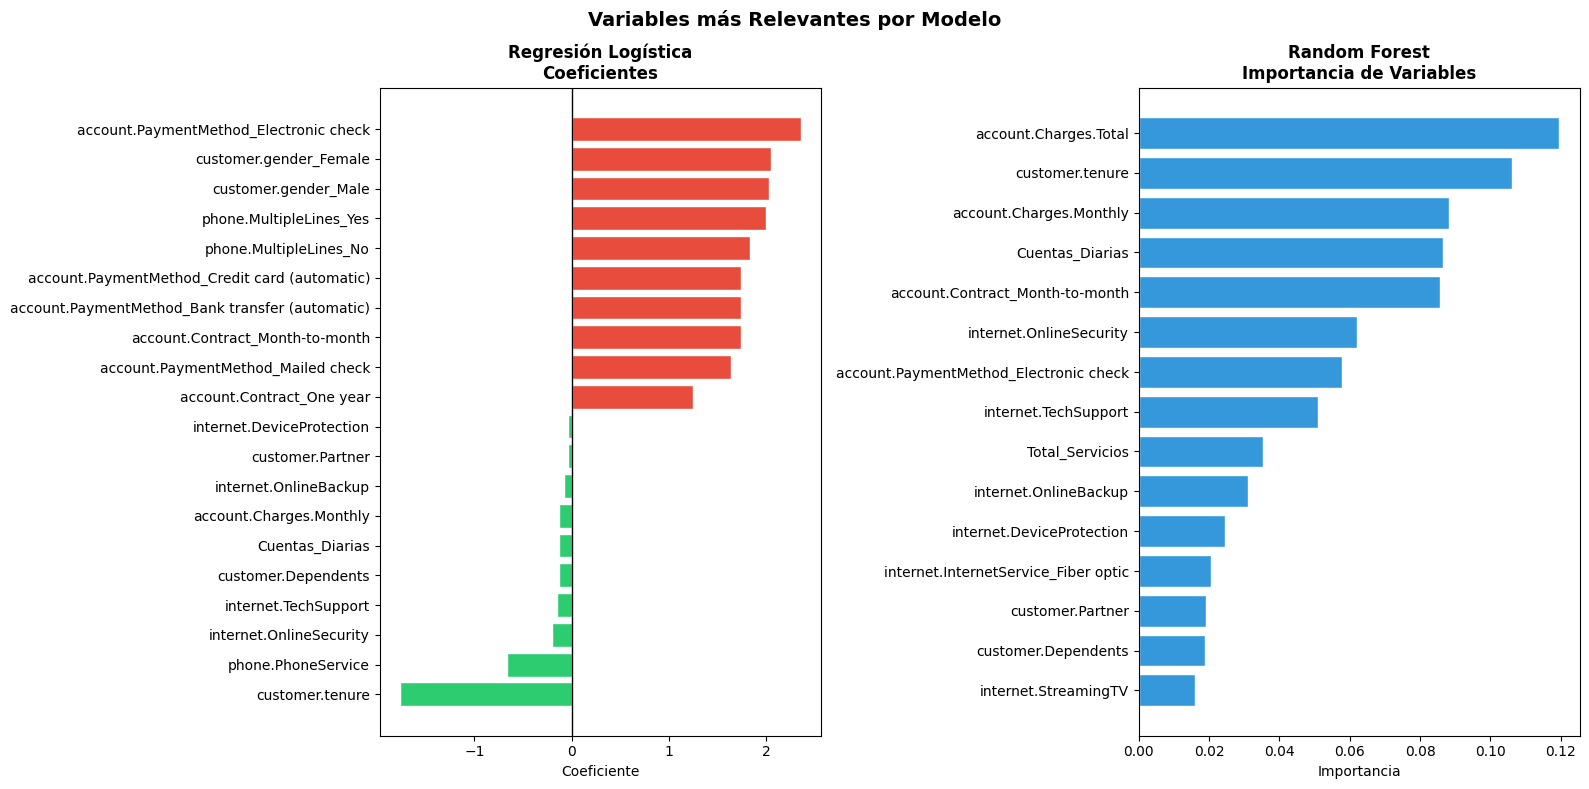

🔴 Top 5 variables que AUMENTAN evasión (LR):
phone.MultipleLines_No                    1.835
phone.MultipleLines_Yes                   1.995
customer.gender_Male                      2.027
customer.gender_Female                    2.048
account.PaymentMethod_Electronic check    2.353

🟢 Top 5 variables que REDUCEN evasión (LR):
customer.tenure           -1.766
phone.PhoneService        -0.662
internet.OnlineSecurity   -0.200
internet.TechSupport      -0.154
customer.Dependents       -0.128

🔵 Top 10 variables más importantes (RF):
account.Charges.Total                     0.120
customer.tenure                           0.106
account.Charges.Monthly                   0.088
Cuentas_Diarias                           0.086
account.Contract_Month-to-month           0.086
internet.OnlineSecurity                   0.062
account.PaymentMethod_Electronic check    0.058
internet.TechSupport                      0.051
Total_Servicios                           0.035
internet.OnlineBackup          

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Variables más Relevantes por Modelo', fontsize=14, fontweight='bold')

coef_lr = pd.Series(lr.coef_[0], index=X.columns).sort_values()
top_lr = pd.concat([coef_lr.head(10), coef_lr.tail(10)])
colores_lr = ['#2ecc71' if v < 0 else '#e74c3c' for v in top_lr.values]

axes[0].barh(top_lr.index, top_lr.values, color=colores_lr, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Regresión Logística\nCoeficientes', fontweight='bold')
axes[0].set_xlabel('Coeficiente')

imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

axes[1].barh(imp_rf.index[::-1], imp_rf.values[::-1], color='#3498db', edgecolor='white')
axes[1].set_title('Random Forest\nImportancia de Variables', fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

print("🔴 Top 5 variables que AUMENTAN evasión (LR):")
print(coef_lr.tail(5).round(3).to_string())
print("\n🟢 Top 5 variables que REDUCEN evasión (LR):")
print(coef_lr.head(5).round(3).to_string())
print("\n🔵 Top 10 variables más importantes (RF):")
print(imp_rf.head(10).round(3).to_string())

## Conclusiones

# Modelos Predictivos de Evasión | Telecom X

---

## 1. Rendimiento de los Modelos

Se entrenaron dos modelos de clasificación para predecir la cancelación de clientes:

| Métrica | Regresión Logística | Random Forest |
|---|---|---|
| Accuracy | 0.8140 | 0.8226 |
| AUC-ROC | 0.8991 | 0.8983 |

Ambos modelos alcanzaron un **AUC-ROC de ~0.90**, lo que indica una excelente capacidad
para distinguir entre clientes que cancelan y los que permanecen. La diferencia entre
ambos es mínima, por lo que los dos son válidos para producción.

> El AUC-ROC es la métrica más importante aquí porque el dataset está desbalanceado
> (~73.5% permanece vs 26.5% evade). Un modelo que siempre predijera "permanece"
> tendría 73.5% de accuracy sin aprender nada útil.

---

## 2. Factores que Influyen en la Cancelación

### Variables que AUMENTAN el riesgo de evasión

**Según Regresión Logística (coeficientes positivos):**

| Variable | Coeficiente | Interpretación |
|---|---|---|
| `PaymentMethod_Electronic check` | +2.353 | Mayor predictor de riesgo — pago sin compromiso automático |
| `gender_Female / Male` | +2.048 / +2.027 | Efecto del encoding — género no es diferenciador real |
| `MultipleLines_Yes / No` | +1.995 / +1.835 | Tener o no múltiples líneas aumenta levemente el riesgo |

**Según Random Forest (importancia):**

| Variable | Importancia | Interpretación |
|---|---|---|
| `account.Charges.Total` | 0.120 | Variable más decisiva — resume tiempo y gasto acumulado |
| `customer.tenure` | 0.106 | Antigüedad del cliente — clave para predecir lealtad |
| `account.Charges.Monthly` | 0.088 | Cargo mensual alto asociado a mayor riesgo |
| `Contract_Month-to-month` | 0.086 | Contrato mensual sin compromiso a largo plazo |
| `PaymentMethod_Electronic check` | 0.058 | Confirmado por ambos modelos como factor de riesgo |

### Variables que REDUCEN el riesgo de evasión

**Según Regresión Logística (coeficientes negativos):**

| Variable | Coeficiente | Interpretación |
|---|---|---|
| `customer.tenure` | -1.766 | Mayor antigüedad = mucho menor probabilidad de irse |
| `phone.PhoneService` | -0.662 | Tener servicio telefónico fideliza al cliente |
| `internet.OnlineSecurity` | -0.200 | Seguridad online genera valor percibido |
| `internet.TechSupport` | -0.154 | Soporte técnico reduce frustración y abandono |
| `customer.Dependents` | -0.128 | Responsabilidades familiares generan estabilidad |

---

## 3. Principales Factores de Cancelación

A partir del análisis combinado de ambos modelos, los **5 factores críticos** son:

**1. Antigüedad del cliente (tenure)**
Es el predictor más poderoso en ambos modelos. Los clientes con menos de 12 meses
tienen una probabilidad de evasión mucho mayor. La relación es clara: a más tiempo,
más lealtad.

**2. Método de pago — Cheque Electrónico**
Confirmado por Regresión Logística (+2.353) y Random Forest (0.058). Los clientes
que pagan con cheque electrónico no tienen un compromiso automático de pago,
lo que facilita la cancelación impulsiva.

**3. Tipo de contrato mes a mes**
Random Forest lo identifica con importancia 0.086. Sin un contrato de largo plazo,
el cliente no tiene ninguna barrera para cancelar en cualquier momento.

**4. Cargo mensual elevado**
Aparece como tercera variable más importante en Random Forest (0.088). Clientes
con facturas altas y sin servicios adicionales que justifiquen el costo tienden
a buscar alternativas más económicas.

**5. Ausencia de servicios de valor agregado**
`OnlineSecurity` y `TechSupport` aparecen como factores de retención en ambos modelos.
Los clientes sin estos servicios tienen menos razones para quedarse.

---

## 4. Estrategias de Retención

**E1 — Programa de fidelización por antigüedad**
Implementar beneficios escalonados según los meses de contrato: descuentos,
upgrades de velocidad o servicios gratuitos al cumplir 6, 12 y 24 meses.
El objetivo es superar la barrera crítica del primer año.

**E2 — Migración al pago automático**
Ofrecer descuento del 5-10% en la factura mensual a clientes que migren
desde cheque electrónico a transferencia bancaria o tarjeta automática.
Reduce la facilidad de cancelación impulsiva.

**E3 — Conversión de contratos mensuales a anuales**
Diseñar ofertas específicas para clientes mes a mes con menos de 6 meses
de antigüedad — el segmento de mayor riesgo. Un descuento del primer mes
gratis al firmar contrato anual puede ser suficiente incentivo.

**E4 — Bundles de servicios de valor agregado**
Promover paquetes que incluyan `OnlineSecurity` y `TechSupport` a precio
reducido. Clientes con más servicios contratados tienen más razones para
quedarse y mayor costo percibido de cambio.

**E5 — Alerta temprana con el modelo predictivo**
Usar el modelo Random Forest (AUC-ROC 0.8983) en producción para identificar
mensualmente los clientes con mayor probabilidad de cancelar. Activar acciones
de retención proactivas antes de que tomen la decisión de irse.

---

## 5. Conclusión

Los modelos desarrollados demuestran que la evasión en Telecom X no es aleatoria
— está fuertemente determinada por variables controlables como el tipo de contrato,
el método de pago y los servicios contratados. Con un AUC-ROC de ~0.90,
la empresa tiene una herramienta confiable para anticiparse a las cancelaciones
y actuar antes de perder al cliente.

La combinación de **Random Forest para predicción** y **Regresión Logística para
interpretabilidad** ofrece tanto poder predictivo como claridad estratégica para
la toma de decisiones del equipo comercial.